In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import SVC

In [3]:
f=pd.read_csv("drug200.csv")
df=pd.DataFrame(f)
x=df.drop("Drug",axis=1)
y=df["Drug"]
x=pd.get_dummies(x)
a,b,c,d=train_test_split(x,y,test_size=0.2,random_state=42)
data={}
for i in range(1,200):
    model=SVC(kernel="rbf",C=i)
    model.fit(a,c)
    pre=model.predict(b)
    acc=accuracy_score(d,pre)
    data[i]=acc
max_key = max(data, key=data.get)
print(max_key-1)

139


In [4]:
model=SVC(kernel="rbf",C=max_key-1)
model.fit(a,c)
pre=model.predict(b)
acc=accuracy_score(d,pre)
acc

0.975

In [5]:
CN=confusion_matrix(d,pre)
CN

array([[ 6,  0,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 0,  0,  4,  1,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0, 15]], dtype=int64)

In [6]:
import seaborn as sns

<Axes: >

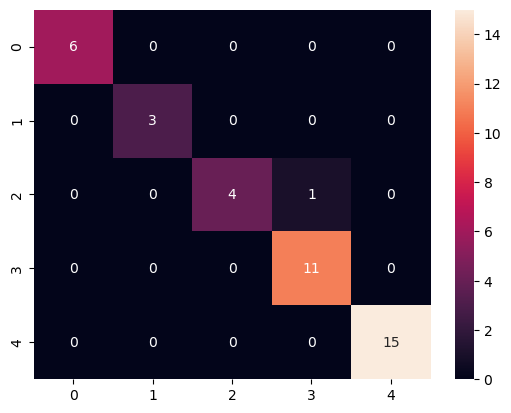

In [7]:
sns.heatmap(CN,annot=True)

In [8]:
f=pd.read_csv("drug200.csv")
df=pd.DataFrame(f)
x=df.drop("Drug",axis=1)
y=df["Drug"]
x=pd.get_dummies(x)
a,b,c,d=train_test_split(x,y,test_size=0.2,random_state=42)
data={}
for i in range(1,max_key):
    model=SVC(kernel="rbf",C=i)
    model.fit(a,c)
    pre=model.predict(b)
    acc=accuracy_score(d,pre)
    data[i]=acc
max_key1 = max(data, key=data.get)
print(max_key1)

125


In [9]:
CN=confusion_matrix(d,pre)
CN

array([[ 6,  0,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 0,  0,  4,  1,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0, 15]], dtype=int64)

In [10]:
cr=classification_report(d,pre)
print(cr)

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      0.80      0.89         5
       drugX       0.92      1.00      0.96        11
       drugY       1.00      1.00      1.00        15

    accuracy                           0.97        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40



### Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
f=pd.read_csv("Churn.csv")
df=pd.DataFrame(f)
df=df.drop("customerID",axis=1)
x=df.drop("Churn",axis=1)
y=df["Churn"]
x=pd.get_dummies(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=RandomForestClassifier(criterion="entropy",max_depth=3,random_state=42,n_estimators=5)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
acc

0.7892122072391767

In [12]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [13]:
CN=confusion_matrix(y_test,pre)
CN

array([[978,  58],
       [239, 134]], dtype=int64)

In [14]:
cr=classification_report(y_test,pre)

In [15]:
print(cr)

              precision    recall  f1-score   support

          No       0.80      0.94      0.87      1036
         Yes       0.70      0.36      0.47       373

    accuracy                           0.79      1409
   macro avg       0.75      0.65      0.67      1409
weighted avg       0.78      0.79      0.76      1409



In [16]:
import seaborn as sns

<Axes: >

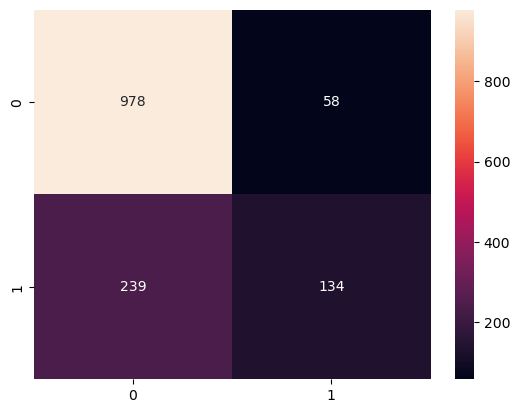

In [17]:
sns.heatmap(CN,annot=True,fmt=".5g")

In [18]:
from sklearn.ensemble import RandomForestClassifier
f=pd.read_csv("Churn.csv")
df=pd.DataFrame(f)
df=df.drop("customerID",axis=1)
x=df.drop("Churn",axis=1)
y=df["Churn"]
x=pd.get_dummies(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
data={}
for i in range(1,100):
    model=RandomForestClassifier(criterion="entropy",max_depth=3,random_state=42,n_estimators=i)
    model.fit(x_train,y_train)
    pre=model.predict(x_test)
    acc=accuracy_score(y_test,pre)
    data[i]=acc
max_key1 = max(data, key=data.get)
print(max_key1)
max_value=max(data.values())
print(max_value)

10
0.7906316536550745
